In [31]:
%env XLA_PYTHON_CLIENT_PREALLOCATE=False
import jax.numpy as jnp
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =============================
# Load all PKL files
# =============================
DIR = "./1_/"
results_list = []
titles_list = []
eps_list = []

for file in os.listdir(DIR):
    if file.endswith(".pkl"):
        # Load pickle
        with open(os.path.join(DIR, file), "rb") as f:
            my_pkl = pickle.load(f)

        # Append 5th element of 'res'
        results_list.append(my_pkl['res'][4])
        titles_list.append(file)

        # Parse eps from filename: assumes 'eps0.1000' style
        eps_val = float(my_pkl['config']['eps'])
        eps_list.append(eps_val)

# =============================
# Build pandas DataFrame
# =============================
df = pd.DataFrame({
    "filename": titles_list,
    "eps": eps_list,
    "res5": results_list
})

# Sort by eps for convenience
df = df.sort_values("eps").reset_index(drop=True)

print(df.head())

# =============================
# Example: iterate over eps and do something
# =============================
for eps_val, group in df.groupby("eps"):
    # For illustration: print shape of the 5th result
    print(f"eps={eps_val}: number of entries = {len(group)}, shapes = {[r.shape if hasattr(r, 'shape') else None for r in group['res5']]}")


# =============================
# Concatenate results for each epsilon
# =============================
# Store as new column 'res5_concat' for each epsilon
df_concat = (
    df.groupby("eps")["res5"]
      .apply(lambda x: np.concatenate(x.values, axis=0))
      .reset_index()
      .rename(columns={"res5": "res5_concat"})
)


env: XLA_PYTHON_CLIENT_PREALLOCATE=False
                           filename     eps  \
0  1__eps0.0031_1.py_0311173332.pkl  0.0031   
1  1__eps0.0031_1.py_0311173908.pkl  0.0031   
2  1__eps0.0031_1.py_0311173658.pkl  0.0031   
3  1__eps0.0031_1.py_0311173252.pkl  0.0031   
4  1__eps0.0031_1.py_0311173413.pkl  0.0031   

                                                res5  
0  [[-2.1347578, -1.4314457, 0.0, 0.0, 0.0, 0.0],...  
1  [[-2.133813, -1.4313389, 0.0, 0.0, 0.0, 0.0], ...  
2  [[-2.1471994, -1.3994744, 0.0, 0.0, 0.0, 0.0],...  
3  [[-2.1487918, -1.4221226, 0.0, 0.0, 0.0, 0.0],...  
4  [[-2.1342313, -1.4147542, 0.0, 0.0, 0.0, 0.0],...  
eps=0.0031: number of entries = 10, shapes = [(20, 6), (20, 6), (20, 6), (20, 6), (20, 6), (20, 6), (20, 6), (20, 6), (20, 6), (20, 6)]
eps=0.0063: number of entries = 10, shapes = [(20, 6), (20, 6), (20, 6), (20, 6), (20, 6), (20, 6), (20, 6), (20, 6), (20, 6), (20, 6)]
eps=0.0125: number of entries = 10, shapes = [(20, 6), (20, 6), (20, 6), (

In [32]:
def rel_error(x, y):
    return jnp.abs((x - y) / y)


def computeZ_from_data(my_pkl):
    logZoverZs = my_pkl['res'][4]
    ZoverZs = jnp.exp(logZoverZs)
    Z = jnp.prod(ZoverZs, axis=-1)
    return Z


def Z_med(logZoverZs):
    """
    Given a sequence of logZoverZs of log of Monte-Carlo estimates of ratio
    of normalising constant, compute Z^med given by the product of the median
    estimates for each ratio of normalising constant
    """
    ZoverZs = jnp.exp(logZoverZs)
    medians = jnp.median(ZoverZs, axis=-1)
    return jnp.prod(medians, axis=-1)


def concatenate_logZoverZs(my_pkls, T):
    number_of_pkls = len(my_pkls)
    in_parallel = 1
    if my_pkls:
        in_parallel = my_pkls[0]['res'][4].shape[0]
    logZoverZs = np.zeros(shape=(number_of_pkls, in_parallel, T))
    for idx, pkl in enumerate(my_pkls):
        logZoverZs[idx] = pkl['res'][4]
    logZoverZs = logZoverZs.reshape((-1, T))
    return logZoverZs


In [33]:
true_Z = jnp.exp(my_pkl['config']['logZ'])

In [34]:

# =============================
# Compute jnp.prod(jnp.exp(...), axis=-1) for each epsilon
# =============================
df_concat["prod_exp"] = df_concat["res5_concat"].apply(lambda arr: jnp.prod(jnp.exp(arr), axis=-1))
df_concat["rel_error"] = df_concat["prod_exp"].apply(lambda x: rel_error(x, true_Z))
# =============================
# Now df_concat contains
# eps | res5_concat | prod_exp
# =============================
print(df_concat)

      eps                                        res5_concat  \
0  0.0031  [[-2.1347578, -1.4314457, 0.0, 0.0, 0.0, 0.0],...   
1  0.0063  [[-2.1385274, -1.4222654, 0.0, 0.0, 0.0, 0.0],...   
2  0.0125  [[-2.1380508, -1.4388413, 0.0, 0.0, 0.0, 0.0],...   
3  0.0250  [[-2.1397634, -1.3464062, 0.0, 0.0, 0.0, 0.0],...   
4  0.0500  [[-2.0920496, -1.5209091, 0.0, 0.0, 0.0, 0.0],...   

                                            prod_exp  \
0  [0.028262952, 0.02826467, 0.028161244, 0.02885...   
1  [0.02841629, 0.027233798, 0.028548913, 0.02821...   
2  [0.027962469, 0.029385272, 0.027654821, 0.0294...   
3  [0.03061793, 0.02616025, 0.028406296, 0.028096...   
4  [0.026971927, 0.032637604, 0.025370568, 0.0266...   

                                           rel_error  
0  [0.006803925, 0.006743575, 0.010378069, 0.0140...  
1  [0.0014154144, 0.042969715, 0.003245098, 0.008...  
2  [0.017363306, 0.032635827, 0.02817443, 0.03326...  
3  [0.07595298, 0.08069558, 0.0017666498, 0.01263...  
4  

In [35]:
df_concat

,eps,res5_concat,prod_exp,rel_error
0,0.0031,"[[-2.1347578, -1.4314457, 0.0, 0.0, 0.0, 0.0],...","[0.028262952, 0.02826467, 0.028161244, 0.02885...","[0.006803925, 0.006743575, 0.010378069, 0.0140..."
1,0.0063,"[[-2.1385274, -1.4222654, 0.0, 0.0, 0.0, 0.0],...","[0.02841629, 0.027233798, 0.028548913, 0.02821...","[0.0014154144, 0.042969715, 0.003245098, 0.008..."
2,0.0125,"[[-2.1380508, -1.4388413, 0.0, 0.0, 0.0, 0.0],...","[0.027962469, 0.029385272, 0.027654821, 0.0294...","[0.017363306, 0.032635827, 0.02817443, 0.03326..."
3,0.0250,"[[-2.1397634, -1.3464062, 0.0, 0.0, 0.0, 0.0],...","[0.03061793, 0.02616025, 0.028406296, 0.028096...","[0.07595298, 0.08069558, 0.0017666498, 0.01263..."
4,0.0500,"[[-2.0920496, -1.5209091, 0.0, 0.0, 0.0, 0.0],...","[0.026971927, 0.032637604, 0.025370568, 0.0266...","[0.0521722, 0.14692688, 0.10844598, 0.06294883..."


In [36]:
res5.shape[0]

200

In [37]:
# Assume df_concat has columns:
# eps | res5_concat | prod_exp | prod_exp_f
# And each 'res5_concat' is an array of shape (K, T)
J = 200//4  # number of splits per epsilon

# Prepare a new list to build the expanded DataFrame
expanded_records = []

for _, row in df_concat.iterrows():
    eps = row["eps"]
    res5 = row["res5_concat"]
    prod_exp = row["prod_exp"]
    prod_exp_f = row["rel_error"]

    # Compute chunk sizes
    K = res5.shape[0]
    split_size = K // J
    remainder = K % J  # if not divisible exactly

    # Use np.array_split to handle uneven splits automatically
    res5_splits = np.array_split(np.array(res5), J, axis=0)
    prod_exp_splits = np.array_split(np.array(prod_exp), J, axis=0)
    prod_exp_f_splits = np.array_split(np.array(prod_exp_f), J, axis=0)

    # Append each split as a new row
    for i in range(J):
        expanded_records.append({
            "eps": eps,
            "res5_split": res5_splits[i],
            "prod_exp_split": prod_exp_splits[i],
            "rel_error_split": prod_exp_f_splits[i]
        })

# Build new DataFrame
df_splits = pd.DataFrame(expanded_records)

print(df_splits.head())
print(f"Total rows after splitting: {len(df_splits)}")

      eps                                         res5_split  \
0  0.0031  [[-2.1347578, -1.4314457, 0.0, 0.0, 0.0, 0.0],...   
1  0.0031  [[-2.145721, -1.4045655, 0.0, 0.0, 0.0, 0.0], ...   
2  0.0031  [[-2.1377447, -1.4185301, 0.0, 0.0, 0.0, 0.0],...   
3  0.0031  [[-2.134157, -1.4222864, 0.0, 0.0, 0.0, 0.0], ...   
4  0.0031  [[-2.1479948, -1.415656, 0.0, 0.0, 0.0, 0.0], ...   

                                      prod_exp_split  \
0  [0.028262952, 0.02826467, 0.028161244, 0.02885...   
1  [0.028716415, 0.02833063, 0.028648121, 0.02809...   
2  [0.028544962, 0.028703965, 0.0286515, 0.028406...   
3  [0.028540153, 0.02814918, 0.028653603, 0.02848...   
4  [0.028335193, 0.028639518, 0.028155327, 0.0284...   

                                     rel_error_split  
0  [0.006803925, 0.006743575, 0.010378069, 0.0140...  
1  [0.009131334, 0.0044256574, 0.0067314003, 0.01...  
2  [0.0031062665, 0.008693828, 0.006850137, 0.001...  
3  [0.0029372599, 0.010802026, 0.0069240364, 0.00...  
4  

In [38]:
df_splits["Z_med_rel_error"] = df_splits["res5_split"].apply(lambda x: rel_error(Z_med(x.T), true_Z))

In [39]:
"""
We will compute:

Per chunk: prob_ge_eps_chunk = fraction of rel_error_split >= eps

Per epsilon: Z_med_rel_error_agg = fraction of all rel_error_split in all chunks of that epsilon >= eps
"""



# -----------------------------
# 1️⃣ Per-chunk probability
# -----------------------------
def compute_prob_ge_eps(row):
    # fraction of values in rel_error_split >= eps of the row
    return float(jnp.mean(row["rel_error_split"] >= row["eps"]))

df_splits["failure_prob_chunk"] = df_splits.apply(compute_prob_ge_eps, axis=1)

# -----------------------------
# 2️⃣ Per-epsilon aggregated probability
# -----------------------------
df_splits["failure_prob"] = np.nan  # initialize

for eps_val, group in df_splits.groupby("eps"):
    # Concatenate all rel_error_split arrays for this epsilon
    all_rel_error = np.concatenate(group["rel_error_split"].values, axis=0)
    prob_agg = float(jnp.mean(all_rel_error >= eps_val))

    # Store only in the first row of this epsilon
    first_idx = group.index[0]
    df_splits.at[first_idx, "failure_prob"] = prob_agg
    
    # -----------------------------
# 3️⃣ Per-epsilon median estimator failure probability
# -----------------------------
df_splits["failure_prob_med"] = np.nan

for eps_val, group in df_splits.groupby("eps"):
    
    # each row already corresponds to one median estimator
    med_errors = group["Z_med_rel_error"].values
    
    prob_med_fail = float(np.mean(med_errors >= eps_val))
    
    # store only once per epsilon
    first_idx = group.index[0]
    df_splits.at[first_idx, "failure_prob_med"] = prob_med_fail

In [40]:
df_splits

,eps,res5_split,prod_exp_split,rel_error_split,Z_med_rel_error,failure_prob_chunk,failure_prob,failure_prob_med
0,0.0031,"[[-2.1347578, -1.4314457, 0.0, 0.0, 0.0, 0.0],...","[0.028262952, 0.02826467, 0.028161244, 0.02885...","[0.006803925, 0.006743575, 0.010378069, 0.0140...",0.0047975765,1.00,0.785,0.62
1,0.0031,"[[-2.145721, -1.4045655, 0.0, 0.0, 0.0, 0.0], ...","[0.028716415, 0.02833063, 0.028648121, 0.02809...","[0.009131334, 0.0044256574, 0.0067314003, 0.01...",0.00036753385,1.00,NaN,NaN
2,0.0031,"[[-2.1377447, -1.4185301, 0.0, 0.0, 0.0, 0.0],...","[0.028544962, 0.028703965, 0.0286515, 0.028406...","[0.0031062665, 0.008693828, 0.006850137, 0.001...",0.004106299,0.75,NaN,NaN
3,0.0031,"[[-2.134157, -1.4222864, 0.0, 0.0, 0.0, 0.0], ...","[0.028540153, 0.02814918, 0.028653603, 0.02848...","[0.0029372599, 0.010802026, 0.0069240364, 0.00...",0.0010659463,0.50,NaN,NaN
4,0.0031,"[[-2.1479948, -1.415656, 0.0, 0.0, 0.0, 0.0], ...","[0.028335193, 0.028639518, 0.028155327, 0.0284...","[0.0042652907, 0.0064290604, 0.010586022, 0.00...",0.0026057921,0.75,NaN,NaN
...,...,...,...,...,...,...,...,...
245,0.0500,"[[-2.067975, -1.3972255, 0.0, 0.0, 0.0, 0.0], ...","[0.031266734, 0.02416244, 0.041188523, 0.03087...","[0.098752774, 0.15090115, 0.44741705, 0.08506101]",0.061525557,1.00,NaN,NaN
246,0.0500,"[[-2.1497576, -1.3929735, 0.0, 0.0, 0.0, 0.0],...","[0.028934194, 0.03073989, 0.03322039, 0.025705...","[0.016784351, 0.08023883, 0.16740678, 0.096686...",0.050753444,0.75,NaN,NaN
247,0.0500,"[[-2.1573372, -1.4320158, 0.0, 0.0, 0.0, 0.0],...","[0.027616195, 0.027343065, 0.020971315, 0.0203...","[0.029531786, 0.03912995, 0.26304132, 0.28434402]",0.14752193,0.50,NaN,NaN
248,0.0500,"[[-2.127613, -1.4494029, 0.0, 0.0, 0.0, 0.0], ...","[0.027959006, 0.02620253, 0.029073184, 0.02600...","[0.017484989, 0.0792098, 0.021668656, 0.08601424]",0.013707474,0.50,NaN,NaN


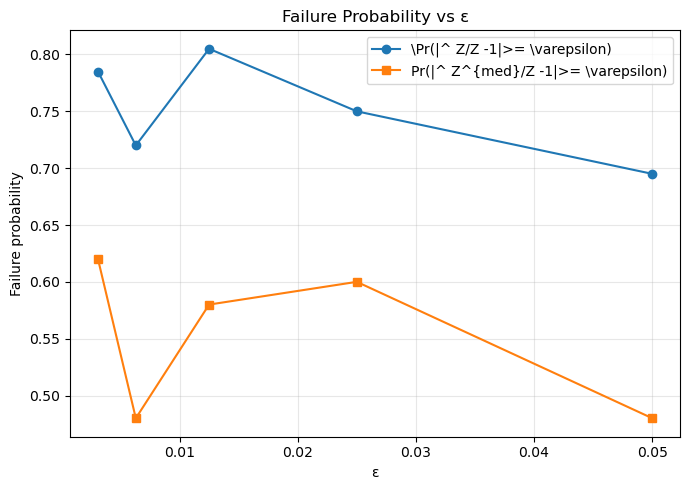

In [41]:
summary = df_splits.dropna(subset=["failure_prob"]).copy()

summary = summary.sort_values("eps")

eps_vals = summary["eps"].values
prob_simple = summary["failure_prob"].values
prob_median = summary["failure_prob_med"].values

fig, ax = plt.subplots(figsize=(7,5))

ax.plot(
    eps_vals,
    prob_simple,
    marker="o",
    label=r"\Pr(|^ Z/Z -1|>= \varepsilon)"
)

ax.plot(
    eps_vals,
    prob_median,
    marker="s",
    label=r"Pr(|^ Z^{med}/Z -1|>= \varepsilon)"
)

ax.set_xlabel(r"ε")
ax.set_ylabel("Failure probability")

ax.set_title("Failure Probability vs ε")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

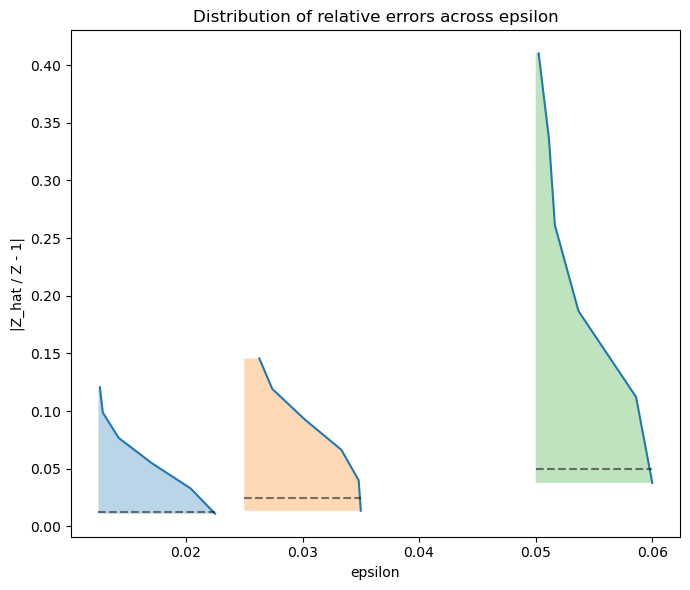

In [30]:
import numpy as np
import matplotlib.pyplot as plt

eps_list = sorted(rel_error_by_eps.keys())

fig, ax = plt.subplots(figsize=(7,6))

width = 0.01
nbins = 6

for eps in eps_list:

    errors = np.array(rel_error_by_eps[eps])

    # Histogram density
    density, bin_edges = np.histogram(errors, bins=nbins, density=True)

    # Bin centers
    y_vals = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Normalize ridge width
    density = density / density.max()

    x_vals = eps + density * width

    # Plot ridge
    ax.plot(x_vals, y_vals, color="tab:blue")
    ax.fill_betweenx(y_vals, eps, x_vals, alpha=0.3)

    # Dashed threshold segment only across ridge
    idx = np.searchsorted(bin_edges, eps) - 1
    if 0 <= idx < len(density):
        dens_eps = density[idx]
        x_end = eps + dens_eps * width
        ax.plot([eps, x_end], [eps, eps], linestyle="--", color="black", alpha=0.5)

ax.set_xlabel("epsilon")
ax.set_ylabel("|Z_hat / Z - 1|")
ax.set_title("Distribution of relative errors across epsilon")

plt.tight_layout()
plt.show()

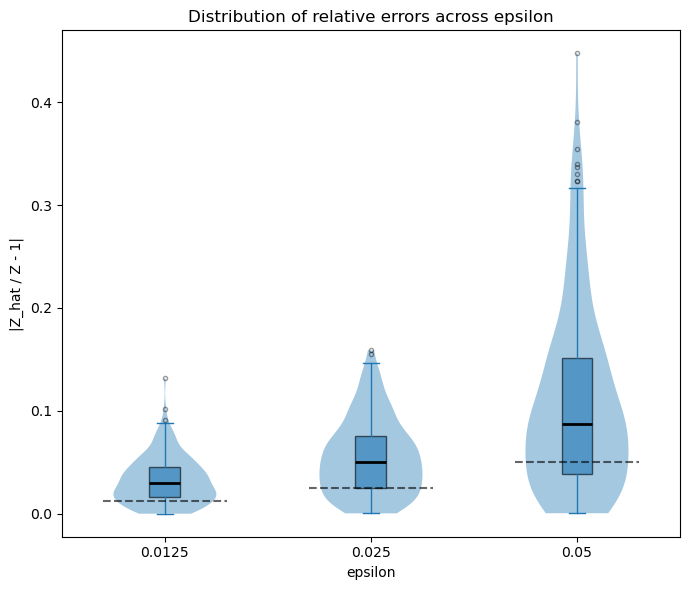

In [16]:
import numpy as np
import matplotlib.pyplot as plt

eps_list = sorted(rel_error_by_eps.keys())
fig, ax = plt.subplots(figsize=(7, 6))

data = [np.array(rel_error_by_eps[eps]) for eps in eps_list]

# Violin plot
parts = ax.violinplot(data, positions=range(len(eps_list)),
                      showmedians=False, showextrema=False)

for pc in parts["bodies"]:
    pc.set_facecolor("tab:blue")
    pc.set_alpha(0.4)

# Box plot overlaid
bp = ax.boxplot(data, positions=range(len(eps_list)),
                widths=0.15, patch_artist=True,
                medianprops=dict(color="black", linewidth=2),
                boxprops=dict(facecolor="tab:blue", alpha=0.6),
                whiskerprops=dict(color="tab:blue"),
                capprops=dict(color="tab:blue"),
                flierprops=dict(marker="o", markersize=3,
                                color="tab:blue", alpha=0.4))

# Dashed threshold line y=eps at each position
for k, eps in enumerate(eps_list):
    ax.plot([k - 0.3, k + 0.3], [eps, eps],
            linestyle="--", color="black", alpha=0.6)

ax.set_xticks(range(len(eps_list)))
ax.set_xticklabels([str(e) for e in eps_list])
ax.set_xlabel("epsilon")
ax.set_ylabel("|Z_hat / Z - 1|")
ax.set_title("Distribution of relative errors across epsilon")
plt.tight_layout()
plt.show()